# VQA CLIP v2 - Kaggle Edition 🚀

Visual Question Answering với **Multi-Head Attention Architecture**

## 🎯 Các bước chạy trên Kaggle:

1. **Add Dataset**: Thêm VizWiz VQA dataset vào notebook
2. **Enable GPU**: Settings → Accelerator → GPU T4 x2
3. **Enable Internet**: Settings → Internet → ON (để tải CLIP model)
4. **Run All**: Chạy tất cả cells từ đầu đến cuối

## 🧠 Kiến trúc (3-Layer Multi-Head Attention):
```
CLIP Encoders (768-dim vision, 512-dim text)
    ↓
Visual Self-Attention (8 heads)
    ↓
Textual Self-Attention (8 heads)
    ↓
Multi-Head Cross-Attention (8 heads)
  - Attention Layer
  - Residual + LayerNorm
  - Feed-Forward Network (512 → 2048 → 512)
  - Residual + LayerNorm
    ↓
Fusion → Classification (100 classes)
```

## ✨ Key Features:
- **8-head attention** ở mỗi layer (Visual, Textual, Cross)
- **Residual connections** + **LayerNorm** (chuẩn Transformer)
- **Feed-Forward Network** sau Cross-Attention
- **Soft Target Loss** với consensus distribution
- **Strong regularization** (dropout 0.4, weight decay 5e-5)

In [1]:
# import json
# from collections import Counter

# # Đường dẫn tới file train.json
# train_file = '/kaggle/input/vizwiz-vqa/data/Annotations/train.json'

# # Load train annotations
# with open(train_file, 'r', encoding='utf-8') as f:
#     train_annotations = json.load(f)

# # Đếm tất cả answers
# answer_counter = Counter()
# for item in train_annotations:
#     if 'answers' in item:
#         for ans_obj in item['answers']:
#             answer = ans_obj['answer'].strip().lower()
#             answer_counter[answer] += 1

# # Tổng số answers khác nhau
# num_unique_answers = len(answer_counter)
# print(f"Tổng số answer khác nhau trong tập train: {num_unique_answers}")

# # Nếu muốn, in top 10 câu trả lời phổ biến nhất
print("Top 10 câu trả lời phổ biến nhất:")
# for ans, count in answer_counter.most_common(10):
#     print(f"{ans}: {count}")


Top 10 câu trả lời phổ biến nhất:


## 1. Install & Import Libraries

In [2]:
# Install required packages - UPDATED for compatibility
!pip install -q --upgrade huggingface_hub
!pip install -q 'tokenizers>=0.21,<0.22'
!pip install -q --upgrade transformers accelerate sentencepiece

print("✅ Packages installed and upgraded successfully!")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.9/520.9 kB 13.9 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
tokenizers 0.21.2 requires huggingface-hub<1.0,>=0.16.4, but you have huggingface-hub 1.2.1 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.4 which is incompatible.
transformers 4.53.3 requires huggingface-hub<1.0,>=0.30.0, but you have huggingface-hub 1.2.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 13.2 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyar

In [3]:
# Fix tokenizers parallelism warning on Kaggle
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import CLIPModel, CLIPProcessor

from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

from torchvision import transforms

print("✅ All libraries imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎮 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📱 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

2025-12-09 14:04:46.565965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765289086.877234      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765289086.969755      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✅ All libraries imported successfully!
🔥 PyTorch version: 2.6.0+cu124
🎮 CUDA available: True
📱 GPU: Tesla P100-PCIE-16GB
💾 GPU Memory: 15.9 GB


## 2. Configuration - Kaggle Paths

In [16]:
# =====================
# KAGGLE PATHS CONFIGURATION
# =====================
# Thay đổi paths này theo dataset của bạn trên Kaggle

# Dataset paths (Kaggle input)
# Tìm VizWiz dataset trong /kaggle/input
import glob
print("🔍 Detecting VizWiz dataset...")
input_dirs = os.listdir('/kaggle/input')
print(f"Available datasets: {input_dirs}")

# Thử các tên dataset phổ biến
possible_names = [
    'vizwiz-vqa',
    'vizwiz',
    'vizwiz-vqa-dataset',
    'vizwiz-visual-question-answering'
]

DATASET_DIR = None
for name in possible_names:
    if name in input_dirs:
        DATASET_DIR = f'/kaggle/input/{name}'
        break

if DATASET_DIR is None:
    # Lấy thư mục đầu tiên nếu không tìm thấy
    DATASET_DIR = f'/kaggle/input/{input_dirs[0]}'
    print(f"⚠️ Using first dataset: {DATASET_DIR}")
else:
    print(f"✅ Found VizWiz dataset: {DATASET_DIR}")

# Liệt kê cấu trúc thư mục
print(f"\n📂 Dataset structure:")
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Chỉ hiện 5 files đầu
        print(f'{subindent}{file}')
    if len(files) > 5:
        print(f'{subindent}... and {len(files)-5} more files')

# Auto-detect annotation và image paths
def find_files(base_dir, patterns):
    """Tìm file theo patterns"""
    for pattern in patterns:
        files = glob.glob(os.path.join(base_dir, '**', pattern), recursive=True)
        if files:
            return files[0]
    return None

# Tìm annotation files
TRAIN_JSON = find_files(DATASET_DIR, ['*train*.json', 'train.json', 'Annotations/train.json'])
VAL_JSON = find_files(DATASET_DIR, ['*val*.json', 'val.json', 'Annotations/val.json'])
TEST_JSON = find_files(DATASET_DIR, ['*test*.json', 'test.json', 'Annotations/test.json'])

# Tìm image directories
def find_image_dir(base_dir, split):
    """Tìm thư mục ảnh"""
    patterns = [
        f'*{split}*',
        f'{split}',
        f'{split.capitalize()}',
        'Images'
    ]
    
    for root, dirs, files in os.walk(base_dir):
        for pattern in patterns:
            if pattern in os.path.basename(root):
                # Kiểm tra xem có file ảnh không
                image_files = [f for f in os.listdir(root) if f.endswith(('.jpg', '.png'))]
                if image_files:
                    return root
    
    return None

TRAIN_IMG_DIR = find_image_dir(DATASET_DIR, 'train')
VAL_IMG_DIR = find_image_dir(DATASET_DIR, 'val')
TEST_IMG_DIR = find_image_dir(DATASET_DIR, 'test')

# Output paths
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
RESULTS_DIR = '/kaggle/working/results'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Verify paths
print(f"\n✅ Detected paths:")
print(f"  📁 Dataset base: {DATASET_DIR}")
print(f"  📄 Train JSON: {TRAIN_JSON if TRAIN_JSON else '❌ NOT FOUND'}")
print(f"  📄 Val JSON: {VAL_JSON if VAL_JSON else '❌ NOT FOUND'}")
print(f"  📄 Test JSON: {TEST_JSON if TEST_JSON else '❌ NOT FOUND'}")
print(f"  🖼️ Train images: {TRAIN_IMG_DIR if TRAIN_IMG_DIR else '❌ NOT FOUND'}")
print(f"  🖼️ Val images: {VAL_IMG_DIR if VAL_IMG_DIR else '❌ NOT FOUND'}")
print(f"  🖼️ Test images: {TEST_IMG_DIR if TEST_IMG_DIR else '❌ NOT FOUND'}")

# Verify counts
if TRAIN_IMG_DIR and os.path.exists(TRAIN_IMG_DIR):
    train_images = [f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith(('.jpg', '.png'))]
    print(f"  📊 Train images found: {len(train_images):,}")
if VAL_IMG_DIR and os.path.exists(VAL_IMG_DIR):
    val_images = [f for f in os.listdir(VAL_IMG_DIR) if f.endswith(('.jpg', '.png'))]
    print(f"  📊 Val images found: {len(val_images):,}")
# =====================
# HYPERPARAMETERS
# =====================

# Model config
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
MAX_ANSWERS = 2250
UNFREEZE_LAYERS = 2
DROPOUT_RATE = 0.3

# Training config
BATCH_SIZE = 64
NUM_EPOCHS = 40
NUM_WORKERS = 0

# Learning rates
# LEARNING_RATE_HEAD = 5e-5
LEARNING_RATE_HEAD = 1e-4
# LEARNING_RATE_HEAD = 1.5e-4
LEARNING_RATE_CLIP = 1e-6
WEIGHT_DECAY = 5e-5

# Training techniques
GRADIENT_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 0.001

# Loss config
USE_SOFT_TARGETS = True
USE_FOCAL_LOSS = True
USE_LABEL_SMOOTHING = True
FOCAL_ALPHA = 1.0
FOCAL_GAMMA = 0.7
# LABEL_SMOOTHING_FACTOR = 0.1
LABEL_SMOOTHING_FACTOR = 0.0

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("⚙️ Configuration:")
print(f"  🎯 Device: {device}")
print(f"  📊 Batch size: {BATCH_SIZE}")
print(f"  🔄 Epochs: {NUM_EPOCHS}")
print(f"  📚 Max answers: {MAX_ANSWERS}")
print(f"  🛡️ Dropout: {DROPOUT_RATE}")
print(f"  🎯 Soft targets: {USE_SOFT_TARGETS}")
print(f"  🔥 Focal Loss: {USE_FOCAL_LOSS}")
print(f"  ✨ Label Smoothing: {USE_LABEL_SMOOTHING}")

🔍 Detecting VizWiz dataset...
Available datasets: ['final', 'vizwiz-vqa']
✅ Found VizWiz dataset: /kaggle/input/vizwiz-vqa

📂 Dataset structure:
vizwiz-vqa/
  data/
    Annotations/
      train.json
      test.json
      val.json
    val/
      VizWiz_train_00000007.jpg
      VizWiz_train_00000947.jpg
      VizWiz_train_00001199.jpg
      VizWiz_train_00000187.jpg
      VizWiz_train_00000989.jpg
      ... and 2047 more files
    test/
      VizWiz_val_00002755.jpg
      VizWiz_val_00000182.jpg
      VizWiz_val_00006487.jpg
      VizWiz_val_00002366.jpg
      VizWiz_val_00003735.jpg
      ... and 7745 more files
    train/
      VizWiz_train_00023624.jpg
      VizWiz_train_00006610.jpg
      VizWiz_train_00016106.jpg
      VizWiz_train_00019766.jpg
      VizWiz_train_00015114.jpg
      ... and 18466 more files

✅ Detected paths:
  📁 Dataset base: /kaggle/input/vizwiz-vqa
  📄 Train JSON: /kaggle/input/vizwiz-vqa/data/Annotations/train.json
  📄 Val JSON: /kaggle/input/vizwiz-vqa/data/Anno

## 3. Dataset Class với Augmentation

In [17]:
class VQADatasetV2(Dataset):
    """Dataset với data augmentation và soft labels"""
    
    def __init__(self, image_dir, annotations_file, processor, 
                 max_answers=37805, transform=None, mode='train'):
        self.image_dir = image_dir
        self.processor = processor
        self.transform = transform
        self.mode = mode
        
        # Load annotations
        with open(annotations_file, 'r', encoding='utf-8') as f:
            self.annotations = json.load(f)
        
        print(f"Loaded {len(self.annotations)} samples from {annotations_file}")
        
        if mode == 'train':
            self._build_answer_vocab(max_answers)
        else:
            self.answer_to_idx = None
            self.idx_to_answer = None
    
    def _build_answer_vocab(self, max_answers):
        """Build answer vocabulary from training set"""
        answer_counts = Counter()
        
        for item in self.annotations:
            if 'answers' in item:
                for answer_obj in item['answers']:
                    answer = answer_obj['answer'].lower().strip()
                    answer_counts[answer] += 1
        
        most_common = answer_counts.most_common(max_answers)
        self.answer_to_idx = {answer: idx for idx, (answer, _) in enumerate(most_common)}
        self.idx_to_answer = {idx: answer for answer, idx in self.answer_to_idx.items()}
        
        print(f"Built vocabulary with {len(self.answer_to_idx)} answers")
    
    def set_answer_vocab(self, answer_to_idx, idx_to_answer):
        self.answer_to_idx = answer_to_idx
        self.idx_to_answer = idx_to_answer
    
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        item = self.annotations[idx]
        
        # Load image
        image_path = os.path.join(self.image_dir, item['image'])
        try:
            image = Image.open(image_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color=(255, 255, 255))
        
        # Apply augmentation (PIL transforms only)
        if self.transform:
            image = self.transform(image)
        
        # CLIP processor handles ToTensor + Normalize
        image_inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = image_inputs['pixel_values'].squeeze(0)
        
        question = item['question']
        
        # Process labels and create soft label distribution
        label = -1
        soft_labels = torch.zeros(len(self.answer_to_idx) if self.answer_to_idx else 1, dtype=torch.float32)
        
        if 'answers' in item and self.answer_to_idx is not None:
            answer_counts = Counter()
            for answer_obj in item['answers']:
                answer = answer_obj['answer'].lower().strip()
                if answer in self.answer_to_idx:
                    answer_counts[answer] += 1
            
            if answer_counts:
                total_count = sum(answer_counts.values())
                for answer, count in answer_counts.items():
                    if answer in self.answer_to_idx:
                        idx = self.answer_to_idx[answer]
                        soft_labels[idx] = count / total_count
                
                most_common_answer = answer_counts.most_common(1)[0][0]
                if most_common_answer in self.answer_to_idx:
                    label = self.answer_to_idx[most_common_answer]
        
        return {
            'pixel_values': pixel_values,
            'question': question,
            'label': torch.tensor(label, dtype=torch.long),
            'soft_labels': soft_labels,
            'image_id': item.get('image_id', idx)
        }

print("✅ Dataset class defined")

✅ Dataset class defined


## 4. Data Augmentation Functions

In [18]:
class AdvancedCLIPVQAModel(nn.Module):
    def __init__(self, num_classes, clip_model_name="openai/clip-vit-base-patch32", 
                 unfreeze_layers=1, dropout_rate=0.4):
        super().__init__()
        
        self.num_classes = num_classes
        
        # Load CLIP
        self.clip_model = CLIPModel.from_pretrained(clip_model_name)
        
        # Freeze all first
        for param in self.clip_model.parameters():
            param.requires_grad = False
        
        # Unfreeze last N layers
        if unfreeze_layers > 0:
            vision_layers = list(self.clip_model.vision_model.encoder.layers)
            for layer in vision_layers[-unfreeze_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True
            
            text_layers = list(self.clip_model.text_model.encoder.layers)
            for layer in text_layers[-unfreeze_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True
        
        # Feature dimensions
        self.vision_dim = 768
        self.text_dim = 512
        
        # Visual Self-Attention
        self.vision_self_attn = nn.MultiheadAttention(
            embed_dim=self.vision_dim, num_heads=8, 
            dropout=dropout_rate, batch_first=True
        )
        self.vision_self_norm = nn.LayerNorm(self.vision_dim)
        
        # Textual Self-Attention
        self.text_self_attn = nn.MultiheadAttention(
            embed_dim=self.text_dim, num_heads=8, 
            dropout=dropout_rate, batch_first=True
        )
        self.text_self_norm = nn.LayerNorm(self.text_dim)
        
        # Projection layers
        self.vision_proj = nn.Sequential(
            nn.Linear(self.vision_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.text_proj = nn.Sequential(
            nn.Linear(self.text_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Cross-attention (with full Transformer block)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=512, num_heads=8, 
            dropout=dropout_rate, batch_first=True
        )
        self.cross_attn_norm1 = nn.LayerNorm(512)
        self.cross_attn_norm2 = nn.LayerNorm(512)
        self.cross_attn_ffn = nn.Sequential(
            nn.Linear(512, 2048),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(2048, 512),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion network
        self.fusion_net = nn.Sequential(
            nn.Linear(512 * 2, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for module in [self.vision_proj, self.text_proj, self.fusion_net, self.classifier]:
            for m in module.modules():
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight)
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)
    
    def forward(self, pixel_values, questions):
        device = pixel_values.device
        
        # CLIP encoding
        vision_outputs = self.clip_model.vision_model(pixel_values)
        vision_embeddings = vision_outputs.last_hidden_state
        vision_patches = vision_embeddings[:, 1:, :]  # Remove CLS
        
        text_inputs = {k: v.to(device) for k, v in questions.items()}
        text_outputs = self.clip_model.text_model(**text_inputs)
        text_embeddings = text_outputs.last_hidden_state
        
        # Visual Self-Attention
        vision_self_attended, _ = self.vision_self_attn(
            vision_patches, vision_patches, vision_patches
        )
        vision_refined = self.vision_self_norm(vision_patches + vision_self_attended)
        
        # Textual Self-Attention
        text_self_attended, _ = self.text_self_attn(
            text_embeddings, text_embeddings, text_embeddings
        )
        text_refined = self.text_self_norm(text_embeddings + text_self_attended)
        
        # Project to common space
        vision_proj = self.vision_proj(vision_refined)
        text_proj = self.text_proj(text_refined)
        
        # Cross-attention with Transformer block
        # Step 1: Multi-Head Cross-Attention
        cross_attended, attn_weights = self.cross_attn(
            text_proj, vision_proj, vision_proj
        )
        # Step 2: Residual + LayerNorm
        text_proj = self.cross_attn_norm1(text_proj + cross_attended)
        # Step 3: Feed-Forward Network
        ffn_output = self.cross_attn_ffn(text_proj)
        # Step 4: Residual + LayerNorm
        text_proj = self.cross_attn_norm2(text_proj + ffn_output)
        
        # Fusion
        text_global = text_proj.mean(dim=1)
        # Use the final text_proj (after FFN) for cross_global
        cross_global = text_proj.mean(dim=1)
        fused = torch.cat([text_global, cross_global], dim=1)
        fused = self.fusion_net(fused)
        
        # Classification
        logits = self.classifier(fused)
        
        return logits, attn_weights

print("✅ Model class defined")

✅ Model class defined


## 5. Model với Self-Attention + Cross-Attention

In [19]:
def get_data_transforms():
    """Create augmentation transforms"""
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            transforms.RandomRotation(degrees=10),
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
        ]),
        'test': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
        ])
    }
    return data_transforms

def create_dataloaders(processor, batch_size=32, max_answers=37805, num_workers=2):
    """Create dataloaders"""
    transforms_dict = get_data_transforms()
    
    # Create datasets
    train_dataset = VQADatasetV2(
        image_dir=TRAIN_IMG_DIR,
        annotations_file=TRAIN_JSON,
        processor=processor,
        max_answers=max_answers,
        transform=transforms_dict['train'],
        mode='train'
    )
    
    val_dataset = VQADatasetV2(
        image_dir=VAL_IMG_DIR,
        annotations_file=VAL_JSON,
        processor=processor,
        transform=transforms_dict['val'],
        mode='val'
    )
    
    test_dataset = VQADatasetV2(
        image_dir=TEST_IMG_DIR,
        annotations_file=TEST_JSON,
        processor=processor,
        transform=transforms_dict['test'],
        mode='test'
    )
    
    # Set vocabulary
    val_dataset.set_answer_vocab(train_dataset.answer_to_idx, train_dataset.idx_to_answer)
    test_dataset.set_answer_vocab(train_dataset.answer_to_idx, train_dataset.idx_to_answer)
    
    num_classes = len(train_dataset.answer_to_idx)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                             num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                           num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                            num_workers=num_workers, pin_memory=True)
    
    return train_loader, val_loader, test_loader, num_classes

print("✅ Data loading functions defined")

✅ Data loading functions defined


## 6. Loss Functions

In [20]:
class LabelSmoothingCrossEntropy(nn.Module):
    """Label Smoothing Cross Entropy Loss"""
    def __init__(self, smoothing=0.1, ignore_index=-1):
        super().__init__()
        self.smoothing = smoothing
        self.ignore_index = ignore_index
        self.confidence = 1.0 - smoothing
    
    def forward(self, logits, targets, hard_targets=None):
        """
        Args:
            logits: Model predictions [batch, num_classes]
            targets: Can be either hard labels [batch] or soft labels [batch, num_classes]
            hard_targets: Optional hard labels for filtering [batch]
        """
        # If hard_targets provided, use it for filtering
        if hard_targets is not None:
            valid_mask = hard_targets != self.ignore_index
            if not valid_mask.any():
                return torch.tensor(0.0, device=logits.device, requires_grad=True)
            logits = logits[valid_mask]
            targets = targets[valid_mask]
        else:
            # Otherwise, check if targets are hard labels
            if targets.dim() == 1:
                # Hard labels
                valid_mask = targets != self.ignore_index
                if not valid_mask.any():
                    return torch.tensor(0.0, device=logits.device, requires_grad=True)
                logits = logits[valid_mask]
                targets = targets[valid_mask]
        
        # Get log probabilities
        log_probs = F.log_softmax(logits, dim=-1)
        
        # Check if targets are hard or soft labels
        if targets.dim() == 1:
            # Hard labels: apply label smoothing
            # NLL loss with true class
            nll_loss = -log_probs.gather(dim=-1, index=targets.unsqueeze(1)).squeeze(1)
            
            # Smoothing loss (uniform distribution)
            smooth_loss = -log_probs.mean(dim=-1)
            
            # Combine: (1-smoothing) * nll + smoothing * smooth
            loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        else:
            # Soft labels: treat as soft target loss (no additional smoothing)
            loss = -(targets * log_probs).sum(dim=-1)
        
        return loss.mean()

print("✅ Label Smoothing Cross Entropy defined")

✅ Label Smoothing Cross Entropy defined


## 7. Training Utilities

In [21]:
def get_model_parameters(model, clip_lr, head_lr, weight_decay):
    """Get parameter groups with different learning rates"""
    clip_params = []
    head_params = []
    
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'clip_model' in name:
            clip_params.append(param)
        else:
            head_params.append(param)
    
    return [
        {'params': clip_params, 'lr': clip_lr, 'weight_decay': weight_decay},
        {'params': head_params, 'lr': head_lr, 'weight_decay': weight_decay}
    ]

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_loss = None
        self.best_weights = None
        self.early_stop = False
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            if self.restore_best_weights:
                self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_weights:
                    model.load_state_dict(self.best_weights)
        else:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

print("✅ Training utilities defined")

✅ Training utilities defined


## 8. Training & Validation Functions

In [22]:
def train_epoch(model, dataloader, criterion, optimizer, device, processor, use_soft_targets=False):
    model.train()
    running_loss = 0.0
    running_acc_score = 0.0
    total_samples = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        pixel_values = batch['pixel_values'].to(device)
        raw_questions = batch['question']
        labels = batch['label'].to(device)
        soft_labels = batch['soft_labels'].to(device) if 'soft_labels' in batch else None
        
        valid_mask = labels != -1
        if not valid_mask.any():
            continue
        
        optimizer.zero_grad()
        
        # Tokenize
        tokenized_questions = processor.tokenizer(
            raw_questions, padding=True, truncation=True,
            max_length=77, return_tensors="pt"
        )
        
        # Forward
        logits, _ = model(pixel_values, tokenized_questions)
        
        valid_logits = logits[valid_mask]
        valid_labels = labels[valid_mask]
        
        # Loss
        if use_soft_targets and soft_labels is not None:
            valid_soft_labels = soft_labels[valid_mask]
            loss = criterion(valid_logits, valid_soft_labels, valid_labels)
        else:
            loss = criterion(valid_logits, valid_labels)
        
        # Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        # Stats
        running_loss += loss.item()
        
        # VizWiz VQA accuracy: Acc(ans) = min(#humans that said ans / 3, 1)
        _, preds = torch.max(valid_logits, 1)
        if soft_labels is not None:
            valid_soft_labels = soft_labels[valid_mask]
            for i, pred in enumerate(preds):
                # Get the soft label score for the predicted answer
                # soft_labels[i, pred] represents the fraction of humans who said this answer
                human_count = valid_soft_labels[i, pred].item() * 10  # Convert back to count (max 10 annotators)
                acc_score = min(human_count / 3.0, 1.0)
                running_acc_score += acc_score
        else:
            # Fallback: binary accuracy
            running_acc_score += torch.sum(preds == valid_labels).item()
        
        total_samples += valid_labels.size(0)
        
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.0 * running_acc_score / total_samples:.2f}%'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100.0 * running_acc_score / total_samples
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device, processor, use_soft_targets=False):
    model.eval()
    running_loss = 0.0
    running_acc_score = 0.0
    total_samples = 0
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Validation')
        
        for batch in progress_bar:
            pixel_values = batch['pixel_values'].to(device)
            raw_questions = batch['question']
            labels = batch['label'].to(device)
            soft_labels = batch['soft_labels'].to(device) if 'soft_labels' in batch else None
            
            valid_mask = labels != -1
            if not valid_mask.any():
                continue
            
            tokenized_questions = processor.tokenizer(
                raw_questions, padding=True, truncation=True,
                max_length=77, return_tensors="pt"
            )
            
            logits, _ = model(pixel_values, tokenized_questions)
            
            valid_logits = logits[valid_mask]
            valid_labels = labels[valid_mask]
            
            if use_soft_targets and soft_labels is not None:
                valid_soft_labels = soft_labels[valid_mask]
                loss = criterion(valid_logits, valid_soft_labels, valid_labels)
            else:
                loss = criterion(valid_logits, valid_labels)
            
            running_loss += loss.item()
            
            # VizWiz VQA accuracy: Acc(ans) = min(#humans that said ans / 3, 1)
            _, preds = torch.max(valid_logits, 1)
            if soft_labels is not None:
                valid_soft_labels = soft_labels[valid_mask]
                for i, pred in enumerate(preds):
                    # Get the soft label score for the predicted answer
                    # soft_labels[i, pred] represents the fraction of humans who said this answer
                    human_count = valid_soft_labels[i, pred].item() * 10  # Convert back to count (max 10 annotators)
                    acc_score = min(human_count / 3.0, 1.0)
                    running_acc_score += acc_score
            else:
                # Fallback: binary accuracy
                running_acc_score += torch.sum(preds == valid_labels).item()
            
            total_samples += valid_labels.size(0)
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100.0 * running_acc_score / total_samples
    return epoch_loss, epoch_acc

# def validate_epoch(model, dataloader, criterion, device, processor, use_soft_targets=False):
#     """
#     Validation epoch dùng text-based accuracy, giống logic đoạn code thứ 2.
#     """
#     model.eval()
#     running_loss = 0.0
#     running_acc_score = 0.0
#     total_samples = 0

#     with torch.no_grad():
#         progress_bar = tqdm(dataloader, desc='Validation')

#         for batch in progress_bar:
#             pixel_values = batch['pixel_values'].to(device)
#             raw_questions = batch['question']
#             labels = batch['label'].to(device)  # vẫn dùng cho loss
#             # answers_list = batch['answers']      # danh sách text answers ground truth
#             batch_size = len(batch['image_id'])
#             valid_answers = [gt_dict[batch['image_id'][i]] for i in range(batch_size)]


#             valid_mask = labels != -1
#             if not valid_mask.any():
#                 continue

#             # Tokenize
#             tokenized_questions = processor.tokenizer(
#                 raw_questions, padding=True, truncation=True,
#                 max_length=77, return_tensors="pt"
#             )

#             # Forward
#             logits, _ = model(pixel_values, tokenized_questions)

#             valid_logits = logits[valid_mask]
#             valid_labels = labels[valid_mask]
#             valid_answers = [answers_list[i] for i in range(len(answers_list)) if valid_mask[i]]

#             # Loss vẫn dùng class label
#             loss = criterion(valid_logits, valid_labels)
#             running_loss += loss.item()

#             # -------------------------------
#             # Text-based accuracy (VizWiz style)
#             # -------------------------------
#             _, preds = torch.max(valid_logits, 1)  # index dự đoán
#             batch_size = valid_logits.size(0)

#             for i in range(batch_size):
#                 pred_index = preds[i].item()
#                 # Convert pred_index -> pred_answer text
#                 pred_answer = dataloader.dataset.idx2answer[pred_index].strip().lower()

#                 # Ground truth answers: danh sách 10 answers text
#                 gt_answers = [ans['answer'].strip().lower() for ans in valid_answers[i] if 'answer' in ans]

#                 # Số người trùng với pred
#                 matching_count = sum(1 for ans in gt_answers if ans == pred_answer)

#                 # VizWiz-style accuracy
#                 acc_score = min(matching_count / 3.0, 1.0)
#                 running_acc_score += acc_score

#             total_samples += batch_size

#             progress_bar.set_postfix({
#                 'Loss': f'{loss.item():.4f}',
#                 'Acc': f'{100.0 * running_acc_score / total_samples:.2f}%'
#             })

#     epoch_loss = running_loss / len(dataloader)
#     epoch_acc = 100.0 * running_acc_score / total_samples
#     return epoch_loss, epoch_acc

print("✅ Train/Val functions defined")

✅ Train/Val functions defined


## 9. Load Data

In [23]:
# Load CLIP processor
print("🔄 Loading CLIP processor...")
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
print("✅ Processor loaded!")

# Create dataloaders
print("\n🔄 Creating dataloaders...")
train_loader, val_loader, test_loader, num_classes = create_dataloaders(
    processor=processor,
    batch_size=BATCH_SIZE,
    max_answers=MAX_ANSWERS,
    num_workers=NUM_WORKERS
)
# with open('/kaggle/input/data/Annotations/test.json', 'r') as f:
#     val_annotations = json.load(f)
# gt_dict = {item['image']: item['answers'] for item in val_annotations}

print(f"\n✅ Data loaded!")
print(f"📊 Train: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,} | Test: {len(test_loader.dataset):,}")
print(f"📚 Classes: {num_classes}")

🔄 Loading CLIP processor...
✅ Processor loaded!

🔄 Creating dataloaders...
Loaded 18471 samples from /kaggle/input/vizwiz-vqa/data/Annotations/train.json
Built vocabulary with 2250 answers
Loaded 2052 samples from /kaggle/input/vizwiz-vqa/data/Annotations/val.json
Loaded 4319 samples from /kaggle/input/vizwiz-vqa/data/Annotations/test.json

✅ Data loaded!
📊 Train: 18,471 | Val: 2,052 | Test: 4,319
📚 Classes: 2250


In [24]:
# Xem tất cả files trong folder
!ls /kaggle/input/data/Annotations/test.json

ls: cannot access '/kaggle/input/data/Annotations/test.json': No such file or directory


## 10. Initialize Model

In [25]:
print("🤖 Initializing model...")
model = AdvancedCLIPVQAModel(
    num_classes=num_classes,
    clip_model_name=CLIP_MODEL_NAME,
    unfreeze_layers=UNFREEZE_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model initialized!")
print(f"📊 Total params: {total_params:,}")
print(f"🎯 Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

🤖 Initializing model...
✅ Model initialized!
📊 Total params: 160,791,243
🎯 Trainable params: 29,994,442 (18.7%)


## 11. Setup Training

In [26]:
# Optimizer
param_groups = get_model_parameters(
    model, 
    clip_lr=LEARNING_RATE_CLIP,
    head_lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY
)
optimizer = optim.AdamW(param_groups)

# Loss
if USE_LABEL_SMOOTHING:
    criterion = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING_FACTOR, ignore_index=-1)
    print(f"✅ Loss: Label Smoothing CE (α={LABEL_SMOOTHING_FACTOR})")
elif USE_SOFT_TARGETS:
    criterion = SoftTargetCrossEntropy(ignore_index=-1)
    print("✅ Loss: Soft Target Cross Entropy")
elif USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, ignore_index=-1)
    print("✅ Loss: Focal Loss")
else:
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    print("✅ Loss: Cross Entropy")

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Early stopping
early_stopping = EarlyStopping(
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=MIN_DELTA
)

print("✅ Training setup complete!")

✅ Loss: Label Smoothing CE (α=0.0)
✅ Training setup complete!


## 12. Training Loop

In [27]:
import os
import torch

# Đường dẫn model có sẵn
LOAD_MODEL_PATH = "/kaggle/input/final/other/default/1/max2250drop0.3f_gamma0.7lrh1e-4.pth"

# Nơi muốn lưu model (giống logic save trong code train)
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")

# Load checkpoint
print("📥 Loading pretrained model...")
checkpoint = torch.load(LOAD_MODEL_PATH, map_location=device)

# Nếu bạn có model đã khởi tạo, load weights
model.load_state_dict(checkpoint["model_state_dict"])

# Sau đó save lại đúng format code train dùng
torch.save({
    'epoch': checkpoint.get('epoch', -1),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': checkpoint.get('optimizer_state_dict', None),
    'val_acc': checkpoint.get('val_acc', None),
    'val_loss': checkpoint.get('val_loss', None),
}, best_model_path)

print("✅ Model copied to:", best_model_path)


📥 Loading pretrained model...
✅ Model copied to: /kaggle/working/checkpoints/best_model.pth


In [28]:
# print("🚀 Starting Training!")
# print("=" * 60)


# history = {
#     'train_loss': [],
#     'train_acc': [],
#     'val_loss': [],
#     'val_acc': []
# }

# best_val_acc = 0.0
# best_model_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')

# start_time = time.time()

# for epoch in range(NUM_EPOCHS):
#     print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
#     print("-" * 60)
    
#     # Train
#     train_loss, train_acc = train_epoch(
#         model, train_loader, criterion, optimizer, 
#         device, processor, USE_SOFT_TARGETS
#     )
    
#     # Validate
#     val_loss, val_acc = validate_epoch(
#         model, val_loader, criterion, 
#         device, processor, USE_SOFT_TARGETS
#     )
    
#     # Update scheduler
#     scheduler.step(val_loss)
    
#     # Save history
#     history['train_loss'].append(train_loss)
#     history['train_acc'].append(train_acc)
#     history['val_loss'].append(val_loss)
#     history['val_acc'].append(val_acc)
    
#     # Print stats
#     print(f"\n📊 Epoch {epoch+1} Results:")
#     print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
#     print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
#     print(f"  Gap: {train_acc - val_acc:.2f}%")
    
#     # Save best model
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save({
#             'epoch': epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'val_acc': val_acc,
#             'val_loss': val_loss
#         }, best_model_path)
#         print(f"  ✅ Saved best model! Val Acc: {val_acc:.2f}%")
    
#     # Early stopping
#     early_stopping(val_loss, model)
#     if early_stopping.early_stop:
#         print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
#         break

# training_time = time.time() - start_time

# print(f"\n{'=' * 60}")
# print(f"🎉 Training Complete!")
# print(f"⏱️ Time: {training_time/3600:.2f} hours")
# print(f"🏆 Best Val Acc: {best_val_acc:.2f}%")
# print(f"{'=' * 60}")

## 13. Plot Training History

NameError: name 'history' is not defined

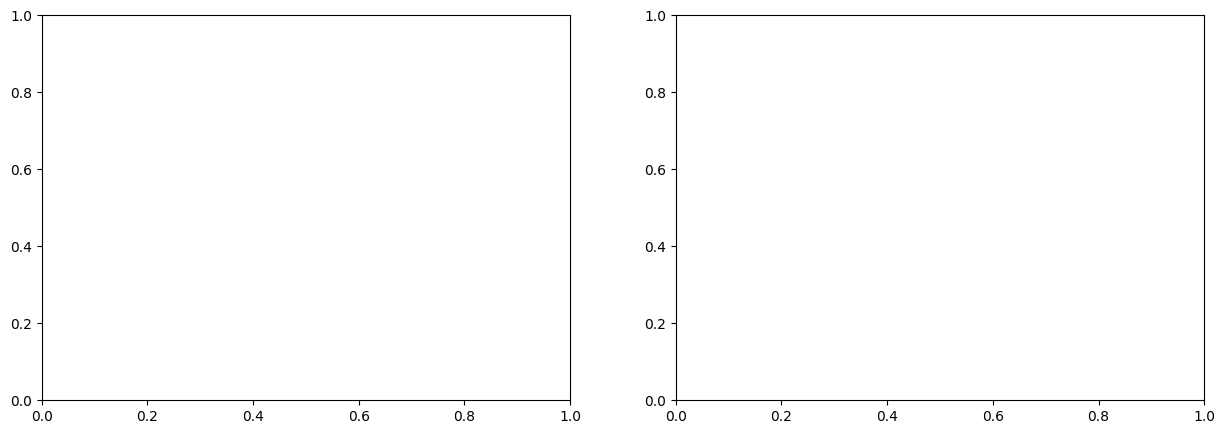

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(history['train_acc']) + 1)

# Accuracy
axes[0].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs, history['val_acc'], 'r-', label='Val', linewidth=2)
axes[0].set_title('Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, history['val_loss'], 'r-', label='Val', linewidth=2)
axes[1].set_title('Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_history.png'), dpi=150)
plt.show()

print("✅ Training curves saved!")

## 14. Evaluate on Test Set

In [ ]:
# Load best model
print("🔄 Loading best model...")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded model from epoch {checkpoint['epoch']+1}")

# Evaluate on test set
print("\n🎯 Evaluating on test set...")
test_loss, test_acc = validate_epoch(
    model, test_loader, criterion, 
    device, processor, USE_SOFT_TARGETS
)

print(f"\n{'=' * 60}")
print(f"🏆 FINAL RESULTS:")
print(f"  📊 Best Val Acc: {best_val_acc:.2f}%")
print(f"  🎯 Test Acc: {test_acc:.2f}%")
print(f"  📈 Test vs Val: {test_acc - best_val_acc:+.2f}%")
print(f"{'=' * 60}")

# Save results
results = {
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'history': history,
    'training_time': training_time
}
torch.save(results, os.path.join(RESULTS_DIR, 'final_results.pth'))
print("💾 Results saved!")

## 15. Visual Demo - 5 Attention Heatmaps từ URLs

Visualize predictions với attention heatmaps cho 5 ảnh mẫu từ URLs

🖼️ Visualizing 5 Demo Predictions with Attention Heatmaps
📊 Visualizing 5 demo samples from URLs


Demo 1/5
Image: Cat
URL: https://images.unsplash.com/photo-1574158622682-e40e69881006?w=400
Question: What animal is this?

⏳ Downloading image...
✅ Image downloaded: (400, 400)
✅ Saved to: /kaggle/working/results/demo_prediction_1.png


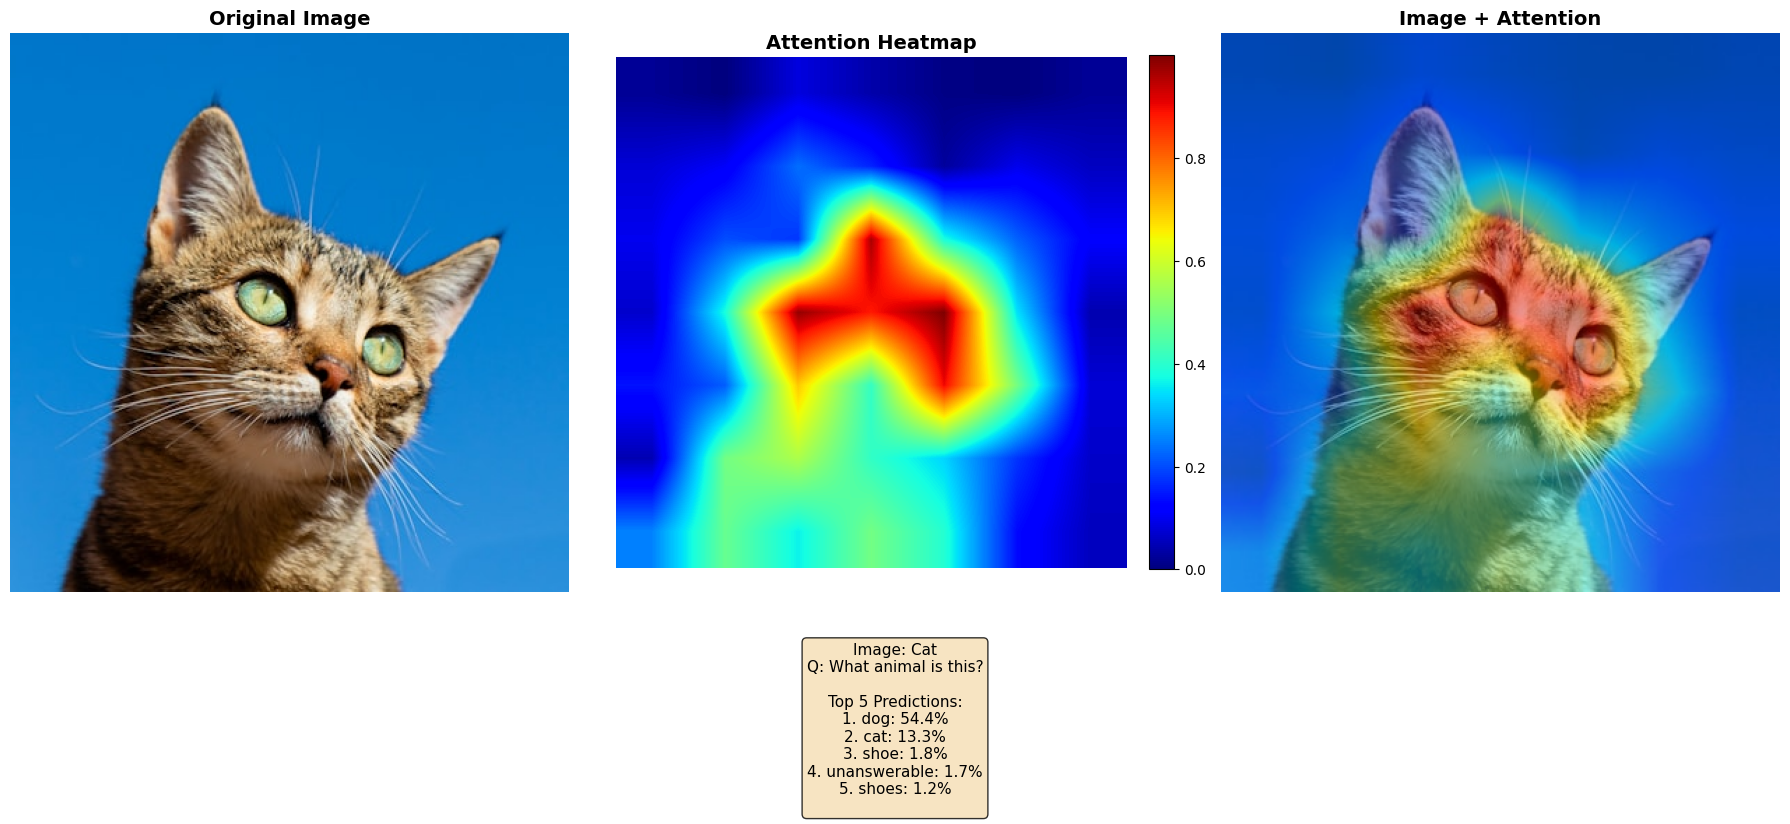


🎯 Top prediction: dog (54.4%)
✅ Demo 1 completed!

Demo 2/5
Image: Dog
URL: https://images.unsplash.com/photo-1552053831-71594a27632d?w=400
Question: What color is the dog?

⏳ Downloading image...
✅ Image downloaded: (400, 641)
✅ Saved to: /kaggle/working/results/demo_prediction_2.png


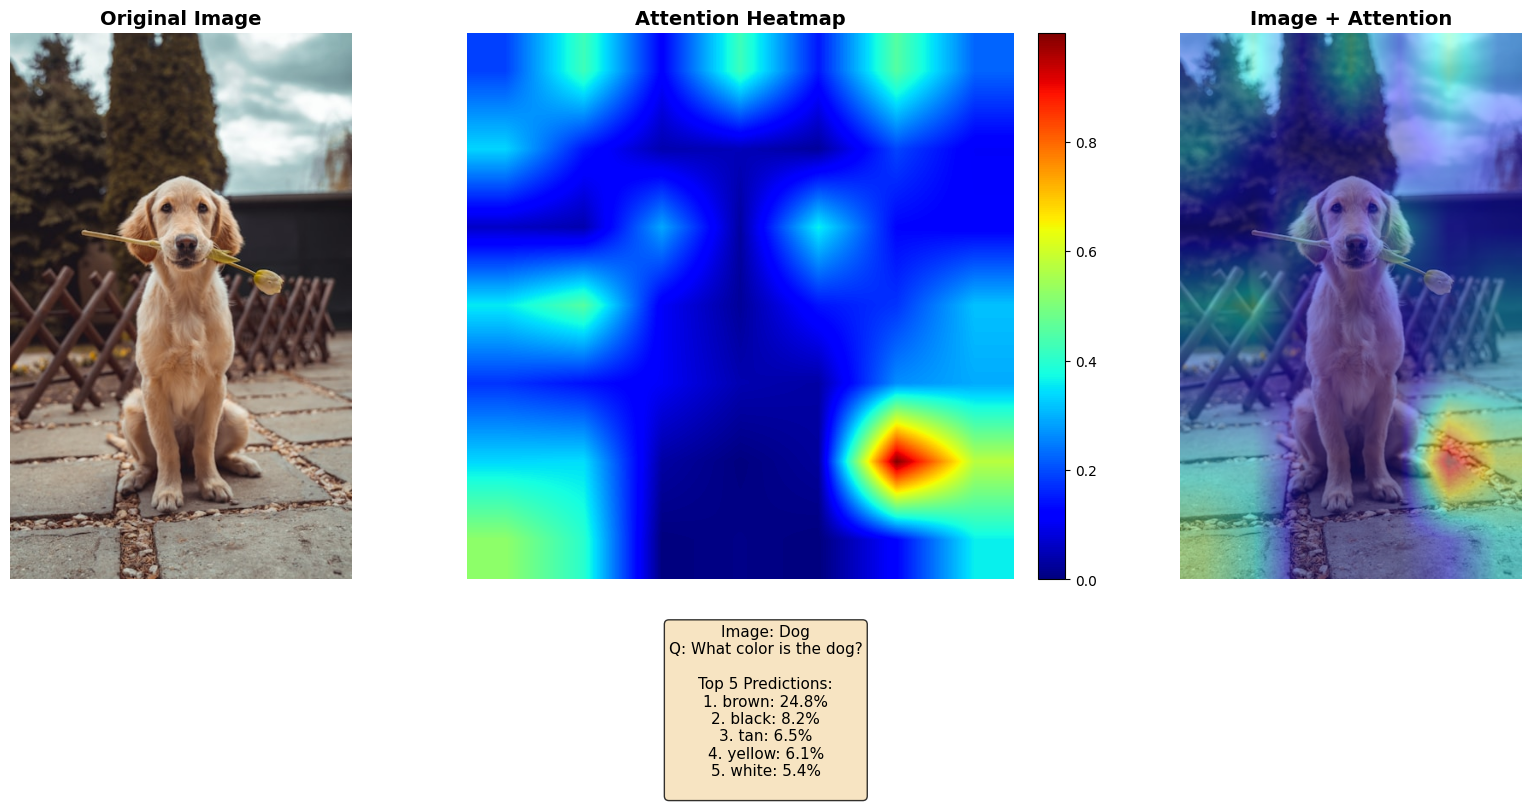


🎯 Top prediction: brown (24.8%)
✅ Demo 2 completed!

Demo 3/5
Image: Food
URL: https://images.unsplash.com/photo-1498837167922-ddd27525d352?w=400
Question: What type of food is shown?

⏳ Downloading image...
✅ Image downloaded: (400, 267)
✅ Saved to: /kaggle/working/results/demo_prediction_3.png


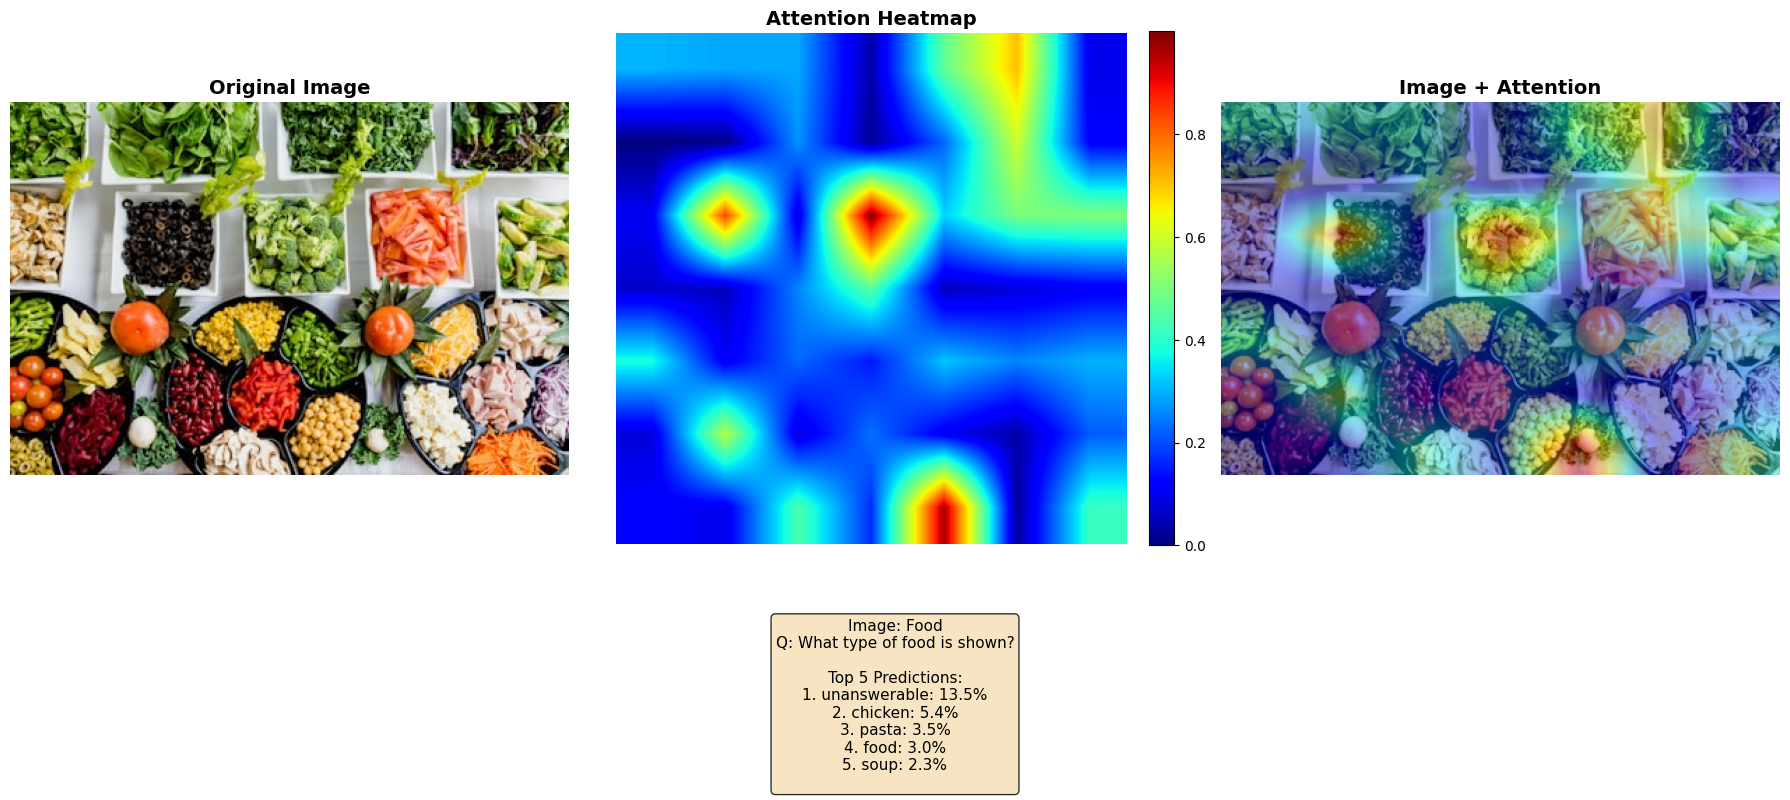


🎯 Top prediction: unanswerable (13.5%)
✅ Demo 3 completed!

Demo 4/5
Image: Mountain
URL: https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400
Question: What is in the background?

⏳ Downloading image...
✅ Image downloaded: (400, 267)
✅ Saved to: /kaggle/working/results/demo_prediction_4.png


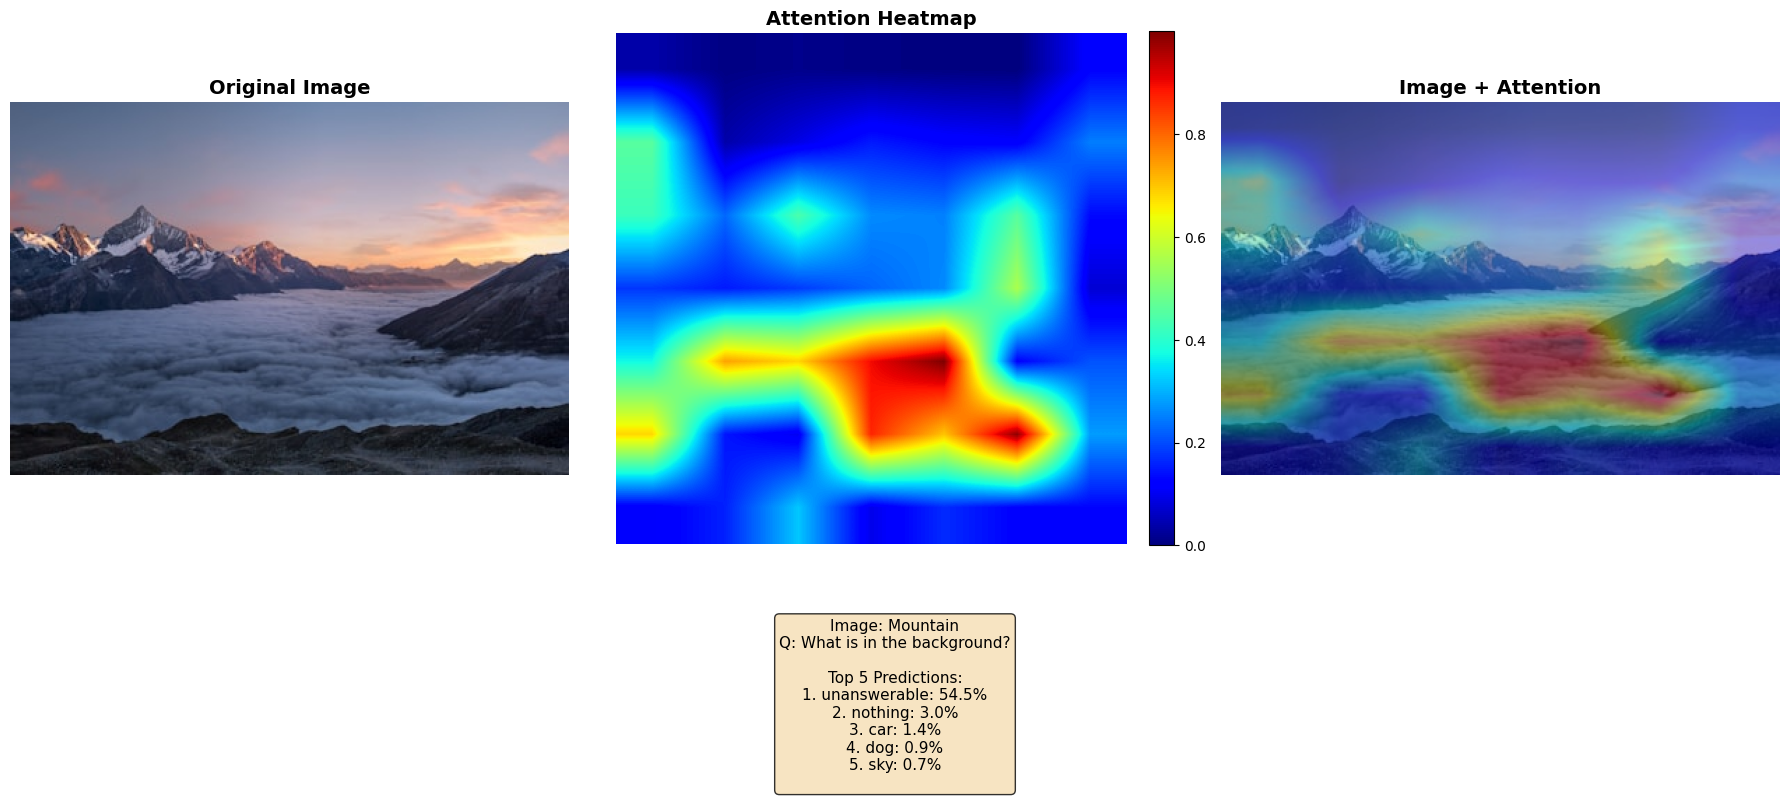


🎯 Top prediction: unanswerable (54.5%)
✅ Demo 4 completed!

Demo 5/5
Image: City
URL: https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=400
Question: Is this a city or countryside?

⏳ Downloading image...
✅ Image downloaded: (400, 267)
✅ Saved to: /kaggle/working/results/demo_prediction_5.png


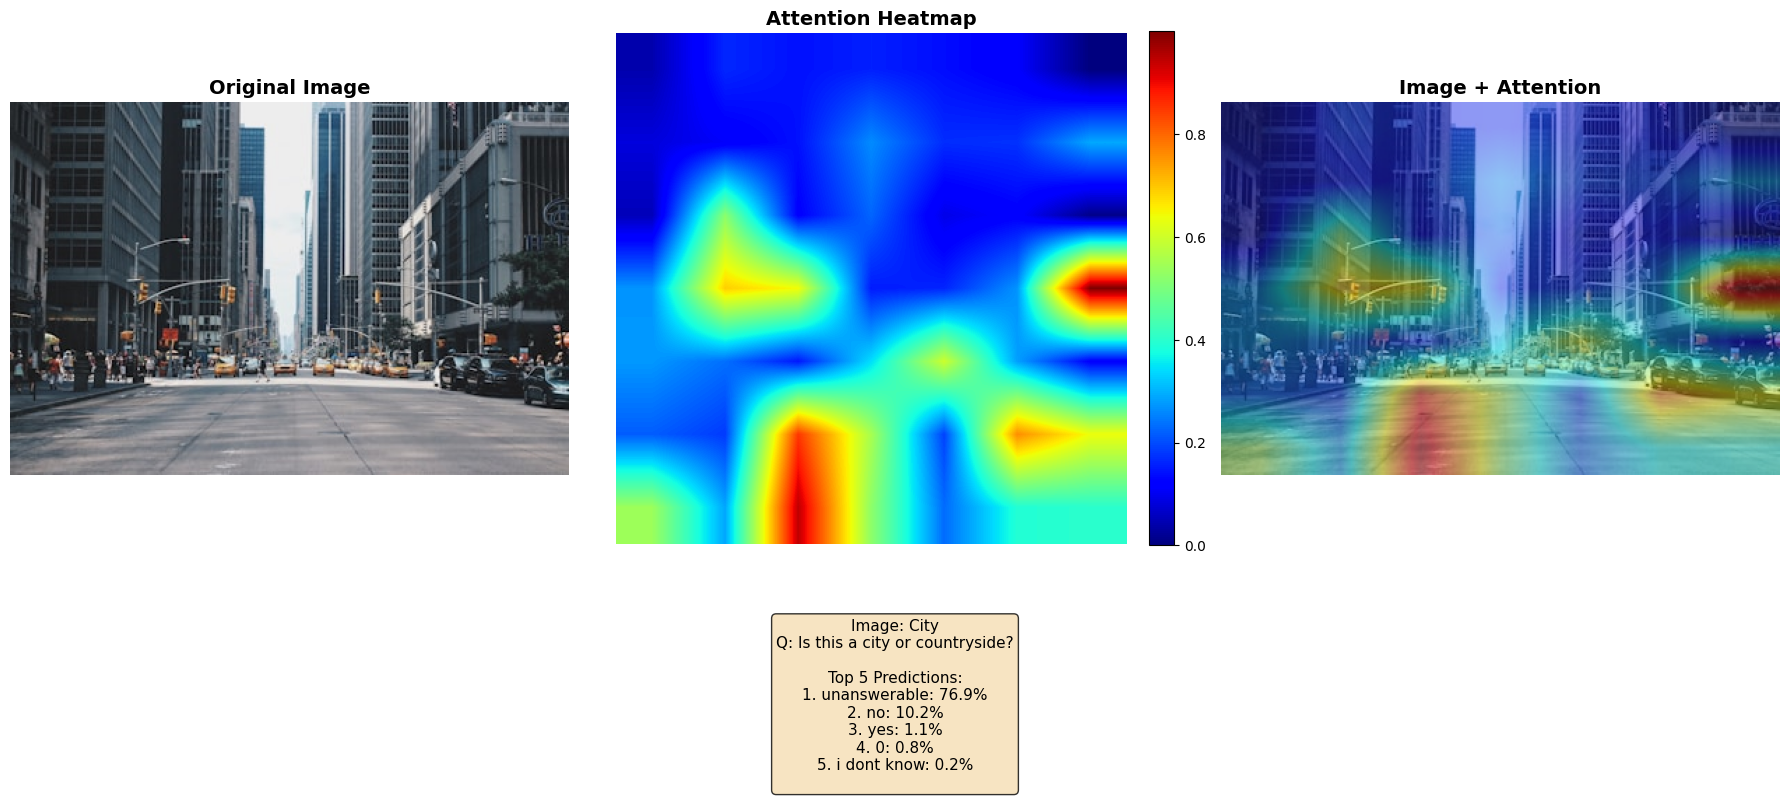


🎯 Top prediction: unanswerable (76.9%)
✅ Demo 5 completed!

🎉 All demo visualizations completed!
📁 Saved 5 demos to: /kaggle/working/results

💡 Tip: You can change URLs in 'demo_samples' to test with different images!


In [30]:
import cv2
from PIL import Image
import torch.nn.functional as F
import os
import requests
from io import BytesIO

def visualize_prediction_with_heatmap(model, image, question, processor, idx_to_answer, device, image_id=None, save_path=None):
    """
    Visualize prediction với attention heatmap
    
    Args:
        model: Trained model
        image: PIL Image object
        question: Question string
        processor: CLIP processor
        idx_to_answer: Dictionary mapping index to answer
        device: Device
        image_id: Optional image ID for display
        save_path: Optional path to save visualization
    """
    # Process với CLIP processor
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device)
    
    # Tokenize question
    tokenized_question = processor.tokenizer(
        question,
        padding=True,
        truncation=True,
        max_length=77,
        return_tensors="pt"
    )
    
    # Forward pass
    model.eval()
    with torch.no_grad():
        logits, attention_weights = model(pixel_values, tokenized_question)
        
        # Get prediction
        probs = F.softmax(logits, dim=-1)
        top5_probs, top5_indices = torch.topk(probs, k=5, dim=-1)
        
        # Get top 5 answers
        top5_answers = [idx_to_answer[idx.item()] for idx in top5_indices[0]]
        top5_scores = top5_probs[0].cpu().numpy()
    
    # Prepare attention heatmap
    # attention_weights: [batch, seq_len, num_patches]
    # Average over sequence length dimension to get [batch, num_patches]
    attn = attention_weights.mean(dim=1)[0].cpu().numpy()  # [num_patches]
    
    # CLIP ViT-B/32 có 49 patches (7x7)
    num_patches = int(np.sqrt(len(attn)))
    attn_map = attn.reshape(num_patches, num_patches)
    
    # Normalize attention map
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    
    # Resize heatmap to image size
    image_np = np.array(image)
    h, w = image_np.shape[:2]
    
    # Resize attention map
    attn_resized = cv2.resize(attn_map, (w, h))
    
    # Create heatmap
    heatmap = cv2.applyColorMap((attn_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay heatmap on image
    overlay = cv2.addWeighted(image_np, 0.6, heatmap, 0.4, 0)
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Attention heatmap
    im = axes[1].imshow(attn_map, cmap='jet', interpolation='bilinear')
    axes[1].set_title('Attention Heatmap', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay
    axes[2].imshow(overlay)
    axes[2].set_title('Image + Attention', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    # Add question and predictions
    if image_id:
        pred_text = f"Image: {image_id}\nQ: {question}\n\n"
    else:
        pred_text = f"Q: {question}\n\n"
    pred_text += "Top 5 Predictions:\n"
    for i, (ans, score) in enumerate(zip(top5_answers, top5_scores), 1):
        pred_text += f"{i}. {ans}: {score*100:.1f}%\n"
    
    fig.text(0.5, -0.05, pred_text, ha='center', va='top', 
             fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Saved to: {save_path}")
    
    plt.show()
    
    return top5_answers, top5_scores


# Get idx_to_answer from train_loader
idx_to_answer = train_loader.dataset.idx_to_answer

# Visualize demo predictions với ảnh từ URLs
print("🖼️ Visualizing 5 Demo Predictions with Attention Heatmaps")
print("=" * 60)

# Demo image URLs và questions
demo_samples = [
    {
        'url': 'https://images.unsplash.com/photo-1574158622682-e40e69881006?w=400',
        'question': 'What animal is this?',
        'id': 'Cat'
    },
    {
        'url': 'https://images.unsplash.com/photo-1552053831-71594a27632d?w=400',
        'question': 'What color is the dog?',
        'id': 'Dog'
    },
    {
        'url': 'https://images.unsplash.com/photo-1498837167922-ddd27525d352?w=400',
        'question': 'What type of food is shown?',
        'id': 'Food'
    },
    {
        'url': 'https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400',
        'question': 'What is in the background?',
        'id': 'Mountain'
    },
    {
        'url': 'https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=400',
        'question': 'Is this a city or countryside?',
        'id': 'City'
    }
]

print(f"📊 Visualizing {len(demo_samples)} demo samples from URLs\n")

# Visualize each sample
demo_count = 0
for i, sample in enumerate(demo_samples, 1):
    print(f"\n{'='*60}")
    print(f"Demo {i}/{len(demo_samples)}")
    print(f"Image: {sample['id']}")
    print(f"URL: {sample['url']}")
    print(f"Question: {sample['question']}")
    print(f"{'='*60}\n")
    
    try:
        # Download image từ URL
        print(f"⏳ Downloading image...")
        response = requests.get(sample['url'], timeout=10)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert('RGB')
        print(f"✅ Image downloaded: {image.size}")
        
        save_path = os.path.join(RESULTS_DIR, f'demo_prediction_{i}.png')
        
        # Visualize
        top5_answers, top5_scores = visualize_prediction_with_heatmap(
            model=model,
            image=image,
            question=sample['question'],
            processor=processor,
            idx_to_answer=idx_to_answer,
            device=device,
            image_id=sample['id'],
            save_path=save_path
        )
        
        print(f"\n🎯 Top prediction: {top5_answers[0]} ({top5_scores[0]*100:.1f}%)")
        print(f"✅ Demo {i} completed!")
        demo_count += 1
        
    except requests.exceptions.RequestException as e:
        print(f"❌ Failed to download image: {e}")
        print(f"💡 Tip: Check internet connection or try different URL")
        continue
    except Exception as e:
        print(f"❌ Failed to visualize demo {i}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*60}")
print(f"🎉 All demo visualizations completed!")
print(f"📁 Saved {demo_count} demos to: {RESULTS_DIR}")
print(f"{'='*60}")

print(f"\n💡 Tip: You can change URLs in 'demo_samples' to test with different images!")

## 16. Multi-Head Attention Visualization (8 Heads)

Visualize tất cả 8 attention heads riêng biệt để hiểu cách mỗi head focus vào các aspects khác nhau của visual-textual alignment

In [31]:
def get_multihead_attention_weights(model, image, question, processor, device):
    """
    Get attention weights từ tất cả 8 heads của cross-attention
    
    Returns:
        multihead_attn_weights: [num_heads, num_text_tokens, num_vision_patches]
    """
    # Process image
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device)
    
    # Tokenize question
    tokenized_question = processor.tokenizer(
        question,
        padding=True,
        truncation=True,
        max_length=77,
        return_tensors="pt"
    )
    
    model.eval()
    
    # Store original forward method
    original_forward = model.cross_attn.forward
    
    def patched_forward(query, key, value, *args, **kwargs):
        # Force không average attention weights
        kwargs['need_weights'] = True
        kwargs['average_attn_weights'] = False
        return original_forward(query, key, value, *args, **kwargs)
    
    # Patch temporarily
    model.cross_attn.forward = patched_forward
    
    try:
        with torch.no_grad():
            # Forward pass thông qua model
            batch_size = pixel_values.shape[0]
            
            # CLIP Vision Encoding
            vision_outputs = model.clip_model.vision_model(pixel_values)
            vision_embeddings = vision_outputs.last_hidden_state
            vision_patch_embeddings = vision_embeddings[:, 1:, :]
            
            # CLIP Text Encoding
            text_inputs = {k: v.to(device) for k, v in tokenized_question.items()}
            text_outputs = model.clip_model.text_model(**text_inputs)
            text_embeddings = text_outputs.last_hidden_state
            
            # Visual Self-Attention
            vision_self_attended, _ = model.vision_self_attn(
                vision_patch_embeddings, vision_patch_embeddings, vision_patch_embeddings
            )
            vision_refined = model.vision_self_norm(vision_patch_embeddings + vision_self_attended)
            
            # Textual Self-Attention
            text_self_attended, _ = model.text_self_attn(
                text_embeddings, text_embeddings, text_embeddings
            )
            text_refined = model.text_self_norm(text_embeddings + text_self_attended)
            
            # Project
            vision_patches_proj = model.vision_proj(vision_refined)
            text_tokens_proj = model.text_proj(text_refined)
            
            # Cross-attention with all heads
            cross_attended, cross_attn_weights = model.cross_attn(
                text_tokens_proj,
                vision_patches_proj,
                vision_patches_proj,
                need_weights=True,
                average_attn_weights=False
            )
            
            # Restore original forward
            model.cross_attn.forward = original_forward
            
            # cross_attn_weights: [batch, num_heads, seq_len, num_patches]
            if cross_attn_weights.dim() == 4:
                return cross_attn_weights[0]  # [num_heads, num_tokens, num_patches]
            elif cross_attn_weights.dim() == 3:
                return cross_attn_weights
            else:
                print(f"⚠️ Unexpected attention shape: {cross_attn_weights.shape}")
                return None
        
    except Exception as e:
        model.cross_attn.forward = original_forward
        print(f"Error getting multi-head attention: {e}")
        import traceback
        traceback.print_exc()
        return None


def visualize_multihead_attention(model, image_url, question, processor, idx_to_answer, device, save_path=None):
    """
    Visualize 8 attention heads riêng biệt
    """
    print(f"🔄 Downloading image from: {image_url}")
    
    # Download image
    response = requests.get(image_url, timeout=10)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert('RGB')
    print(f"✅ Image downloaded: {image.size}")
    
    # Get multi-head attention weights
    print(f"🧠 Computing multi-head attention...")
    multihead_attn = get_multihead_attention_weights(model, image, question, processor, device)
    
    if multihead_attn is None:
        print("❌ Could not extract multi-head attention weights")
        return
    
    # multihead_attn: [num_heads, num_tokens, num_patches]
    num_heads = multihead_attn.shape[0]
    print(f"✅ Got attention from {num_heads} heads")
    print(f"   Shape: {multihead_attn.shape}")
    
    # Average across text tokens to get [num_heads, num_patches]
    head_attentions = multihead_attn.mean(dim=1).cpu().numpy()  # [8, 49]
    
    # Get prediction
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device)
    tokenized_q = processor.tokenizer(question, padding=True, truncation=True, max_length=77, return_tensors="pt")
    
    with torch.no_grad():
        logits, _ = model(pixel_values, tokenized_q)
        probs = F.softmax(logits, dim=-1)
        top5_probs, top5_indices = torch.topk(probs, k=5, dim=-1)
        top5_answers = [idx_to_answer[idx.item()] for idx in top5_indices[0]]
        top5_scores = top5_probs[0].cpu().numpy()
    
    # Create visualization: 1 original + 8 heatmaps
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # Row 1: Original image (span 2 columns) + Info
    ax_orig = fig.add_subplot(gs[0, :2])
    ax_orig.imshow(image)
    ax_orig.set_title('Original Image', fontsize=14, fontweight='bold')
    ax_orig.axis('off')
    
    # Info panel
    ax_info = fig.add_subplot(gs[0, 2:])
    ax_info.axis('off')
    info_text = f"Question: {question}\n\n"
    info_text += "Top 5 Predictions:\n"
    for i, (ans, score) in enumerate(zip(top5_answers, top5_scores), 1):
        info_text += f"{i}. {ans}: {score*100:.1f}%\n"
    
    ax_info.text(0.05, 0.95, info_text, transform=ax_info.transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Rows 2-3: 8 attention heads (2 rows x 4 cols)
    image_np = np.array(image)
    h, w = image_np.shape[:2]
    
    for head_idx in range(min(8, num_heads)):
        row = 1 + head_idx // 4
        col = head_idx % 4
        ax = fig.add_subplot(gs[row, col])
        
        # Get attention for this head
        attn = head_attentions[head_idx]  # [49]
        
        # Reshape to 7x7
        attn_map = attn.reshape(7, 7)
        
        # Normalize
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
        
        # Resize to image size
        attn_resized = cv2.resize(attn_map, (w, h))
        
        # Create heatmap
        heatmap = cv2.applyColorMap((attn_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        # Overlay
        overlay = cv2.addWeighted(image_np, 0.6, heatmap, 0.4, 0)
        
        ax.imshow(overlay)
        ax.set_title(f'Head {head_idx + 1}', fontsize=11, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle('Multi-Head Cross-Attention Visualization (8 Heads)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"✅ Saved to: {save_path}")
    
    plt.tight_layout()
    plt.show()


print("✅ Multi-head attention visualization functions loaded!")

✅ Multi-head attention visualization functions loaded!


🎨 Multi-Head Attention Visualization Demo

📸 Demo Image URL: https://vizwiz.cs.colorado.edu/VizWiz_visualization_img/VizWiz_train_00000024.jpg
❓ Question: Can you see the piece of mail and can you tell me who this mail is for?

🔄 Downloading image from: https://vizwiz.cs.colorado.edu/VizWiz_visualization_img/VizWiz_train_00000024.jpg
✅ Image downloaded: (360, 480)
🧠 Computing multi-head attention...
✅ Got attention from 8 heads
   Shape: torch.Size([8, 20, 49])
✅ Saved to: /kaggle/working/results/questi_5.png


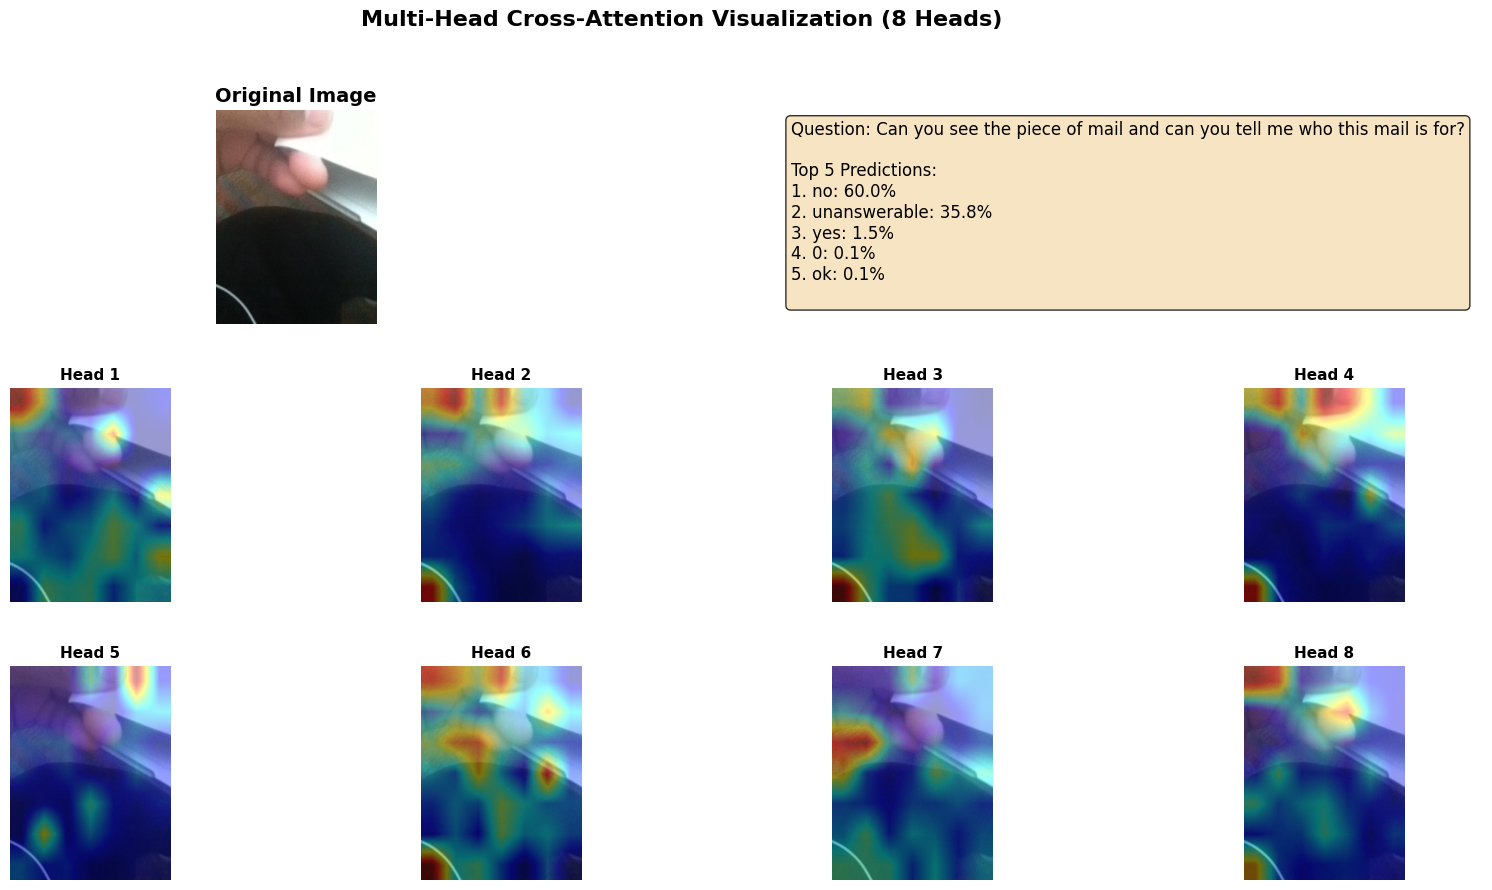


✅ Multi-head visualization completed!
📁 Saved to: /kaggle/working/results/questi_5.png

💡 Tip: Each head learns different aspects of visual-textual alignment!
   - Some heads focus on objects
   - Some heads focus on colors/textures
   - Some heads focus on spatial relationships


In [47]:
# Demo: Visualize 8 attention heads
print("🎨 Multi-Head Attention Visualization Demo")
print("=" * 60)

# Demo image và question
demo_url = "https://vizwiz.cs.colorado.edu/VizWiz_visualization_img/VizWiz_train_00000024.jpg"
demo_question = "Can you see the piece of mail and can you tell me who this mail is for?"



print(f"\n📸 Demo Image URL: {demo_url}")
print(f"❓ Question: {demo_question}\n")

try:
    save_path = os.path.join(RESULTS_DIR, 'questi_5.png')
    
    visualize_multihead_attention(
        model=model,
        image_url=demo_url,
        question=demo_question,
        processor=processor,
        idx_to_answer=idx_to_answer,
        device=device,
        save_path=save_path
    )
    
    print(f"\n✅ Multi-head visualization completed!")
    print(f"📁 Saved to: {save_path}")
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 60)
print("💡 Tip: Each head learns different aspects of visual-textual alignment!")
print("   - Some heads focus on objects")
print("   - Some heads focus on colors/textures")
print("   - Some heads focus on spatial relationships")

## 17. Summary 

In [ ]:
print("📋 VQA CLIP v2 - Kaggle Experiment Summary")
print("=" * 60)

print(f"\n🎯 Dataset:")
print(f"  - Train: {len(train_loader.dataset):,}")
print(f"  - Val: {len(val_loader.dataset):,}")
print(f"  - Test: {len(test_loader.dataset):,}")
print(f"  - Classes: {num_classes}")

print(f"\n🤖 Model:")
print(f"  - Total params: {total_params:,}")
print(f"  - Trainable: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

print(f"\n⚙️ Config:")
print(f"  - Epochs trained: {len(history['train_acc'])}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Dropout: {DROPOUT_RATE}")
print(f"  - Soft targets: {USE_SOFT_TARGETS}")

print(f"\n🏆 Results:")
print(f"  - Best val acc: {best_val_acc:.2f}%")
print(f"  - Test acc: {test_acc:.2f}%")
print(f"  - Training time: {training_time/3600:.2f}h")

print(f"\n🧠 Architecture:")
print(f"  1️⃣ CLIP Encoders")
print(f"  2️⃣ Visual Self-Attention")
print(f"  3️⃣ Textual Self-Attention")
print(f"  4️⃣ Cross-Attention")
print(f"  5️⃣ Fusion & Classification")

print(f"\n📁 Saved files:")
print(f"  - Model: {best_model_path}")
print(f"  - Results: {RESULTS_DIR}/")

print(f"\n{'=' * 60}")
print(f"🎉 EXPERIMENT COMPLETED!")
print(f"{'=' * 60}")

In [ ]:
# !zip -r /kaggle/working/aaa.zip /kaggle/working/checkpoints